# Analiza wyników benchmarków kompresji fraktalnej
Celem jest zbadanie kompromisu między czasem kodowania, stopniem kompresji (CR) a jakością obrazu (MSE/PSNR).

### Badane parametry:
* **Rozmiary bloków (max/min block):**
* **Stride:**
* **Max MSE:**
* **TopK:**

In [1]:
from fastfractal.utils.bench_result_analyzes import (
    extract_fractal_benchmarks_extended,
    visualize_bench_result,
)
from fastfractal.utils.visualize import visualize_blocks_from_file

In [2]:
df_max_min = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260121_max_min.json"
)
df_max_topk = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260121_max_topk.json"
)
df_min_topk = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260121_min_topk.json"
)
df_stride_max = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260121_stride_max.json"
)
df_mse_topk = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260121_mse_topk.json"
)
df_mse_stride = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260121_mse_stride.json"
)
df_mse_max = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260121_mse_max.json"
)
df_benchmark = extract_fractal_benchmarks_extended(
    "../benchmarks/out/bench_20260122_benchmark.json"
)

Przygotowana funkcja do analizy pojedynczego testu generuje **5 interaktywnych wykresów w bibliotece Plotly**:
* **Wykresy czasu**: Średnia czasu kompresji w zależności od każdej z badanych cech.
* **Wykresy stopnia kompresji**: Wyniki współczynnika kompresji (CR) w funkcji badanych cech.
* **Mapa ciepła (Heat Map)**: Wizualizacja średniego czasu kompresji w zależności od kombinacji obu cech jednocześnie, co pozwala zidentyfikować najbardziej wymagające obliczeniowo konfiguracje.

### Badanie wpływu rozmiarów bloków (MAX_BLOCK i MIN_BLOCK)
W tej sekcji analizujemy, jak parametry definiujące zakres wielkości bloków w strukturze Quadtree wpływają na efektywność algorytmu.

* **Wykres czasu wykazuje** najkrótszy czas kodowania osiągany jest dla max_block=4. Co istotne, przy bardzo dużych blokach (max_block=32) czas wzrasta dwukrotnie. Wynika to z faktu, że znalezienie dopasowania dla dużego obszaru jest trudniejsze i częściej kończy się niepowodzeniem, co wymusza kosztowny proces podziału bloku (split).

* **Granica opłacalności MAX_BLOCK**: Przy max_block=2 współczynnik kompresji wynosi ok. 0.73x, co oznacza, że plik wynikowy jest większy od oryginału (overhead metadanych). Efektywna kompresja (CR > 1) zaczyna się od rozmiaru bloku 4x4.

* **Najgorszy przypadek (Worst Case)**: Najwyższy czas kodowania występuje przy kombinacji max_block=32 i min_block=2. Jest to konfiguracja najbardziej obciążająca, ponieważ algorytm próbuje dopasować ogromne bloki, a po niepowodzeniu schodzi aż do najniższego poziomu detali.

* **Najlepszy balans** między czasem a strukturą podziału sugeruje, że dla obrazów o standardowej charakterystyce, najbardziej stabilne wyniki czasowe osiągamy przy max_block w przedziale 8-16.

In [3]:
visualize_bench_result(df_max_min, features=["max_block", "min_block"])

### Optymalizacja czasu: Stride vs Max Block
Analiza wpływu parametru `stride` (kroku przeszukiwania puli domenowej) na jakość działania programu, w porównaniu z parametrem `max_block`.

* **Wykres czasu** dla parametru stride wykazuje niemal wykładniczy spadek wraz ze wzrostem parametru. Nawet niewielkie zwiększenie kroku przeszukiwania (np. z 2 na 4) pozwala na ponad trzykrotne przyspieszenie pracy, co czyni stride najskuteczniejszym narzędziem optymalizacji czasowej.

* **Zaskakujący jest wpływ** stride na stopień kompresji (CR). Dane pokazują ciekawą korelację – wraz ze wzrostem stride, stopień kompresji rośnie, co można interpretować że gęstsze przeszukiwanie pozwala znaleźć lepsze dopasowania dla mniejszych bloków.
* **Zalecenie optymalizacyjne**: Aby uzyskać płynne działanie przy zachowaniu przyzwoitego stopnia kompresji, optymalnym ustawieniem jest Stride = 10 lub 12. Dalsze zwiększanie kroku może przestać dawać zauważalne zyski czasowe, a zacząć negatywnie wpływać na jakość wizualną

In [5]:
visualize_bench_result(df_stride_max, features=["max_block", "stride"])

### Wpływ max_mse
Porównanie różnych wartości parametru `max_mse`, w relacji do parametru `max_block`.

* **Znikomy wpływ** parametru Max MSE: Dane z wykresów jednoznacznie pokazują, że zmiana max_mse (w badanym zakresie) ma marginalny wpływ na czas kompresji oraz współczynnik CR.
Algorytm prawdopodobnie dokonuje podziałów ze względu na brak znalezienia dopasowania w puli, a nie z powodu przekroczenia progu błędu.





In [6]:
visualize_bench_result(df_mse_max, features=["max_mse", "max_block"])

### Znaczenie Topk
W tej sekcji badamy wpływ parametru topk, który określa, ile najlepszych dopasowań z puli domenowej jest branych pod uwagę przed ostatecznym wyborem transformacji.

* **Znikomy wpływ** Top-K na wydajność, co sugeruje, że narzut związany z samą iteracją po puli i obliczaniem MSE dla każdej domeny jest znacznie większy niż koszt sortowania i wyboru najlepszych wyników.

* **Dominacja rozmiaru bloku**: Podobnie jak w poprzednich testach, to parametr geometryczny (min_block) determinuje wydajność.

In [7]:
visualize_bench_result(df_min_topk, features=["min_block", "topk"])

## Weryfikacja wizualna i porównanie profili konfiguracyjnych

Ta sekcja kodu służy do praktycznego przetestowania algorytmu na wybranych obrazach testowych (m.in. Lena, Broccoli, Mandrill) i porównania dwóch skrajnych podejść do kompresji fraktalnej:

1.  **Profil Jakościowy (Quality-oriented):** Wykorzystuje szeroki zakres bloków Quadtree (od 2 do 64) oraz gęste przeszukiwanie puli domenowej (`stride=3`). Celem jest uzyskanie jak najwyższej wierności obrazu.
2.  **Profil Wydajnościowy (Benchmark):** Skonfigurowany pod kątem kompromisu jakości oraz stopnia kompresji. Ogranicza rozmiar bloków i drastycznie zwiększa krok przeszukiwania (`stride=12`), co pozwala na błyskawiczne generowanie wyników.

**Wynikiem działania sekcji jest zestawienie obrazów, gdzie dla każdego pliku testowego porównujemy:**
* Obraz oryginalny.
* Rekonstrukcję profilu "Quality" wraz z czasem kodowania i stopniem kompresji (CR).
* Rekonstrukcję profilu "Benchmark" wraz z analogicznymi metrykami.

Pozwala to na bezpośrednią ocenę wizualną artefaktów kompresji w zestawieniu z uzyskanymi zyskami czasowymi.

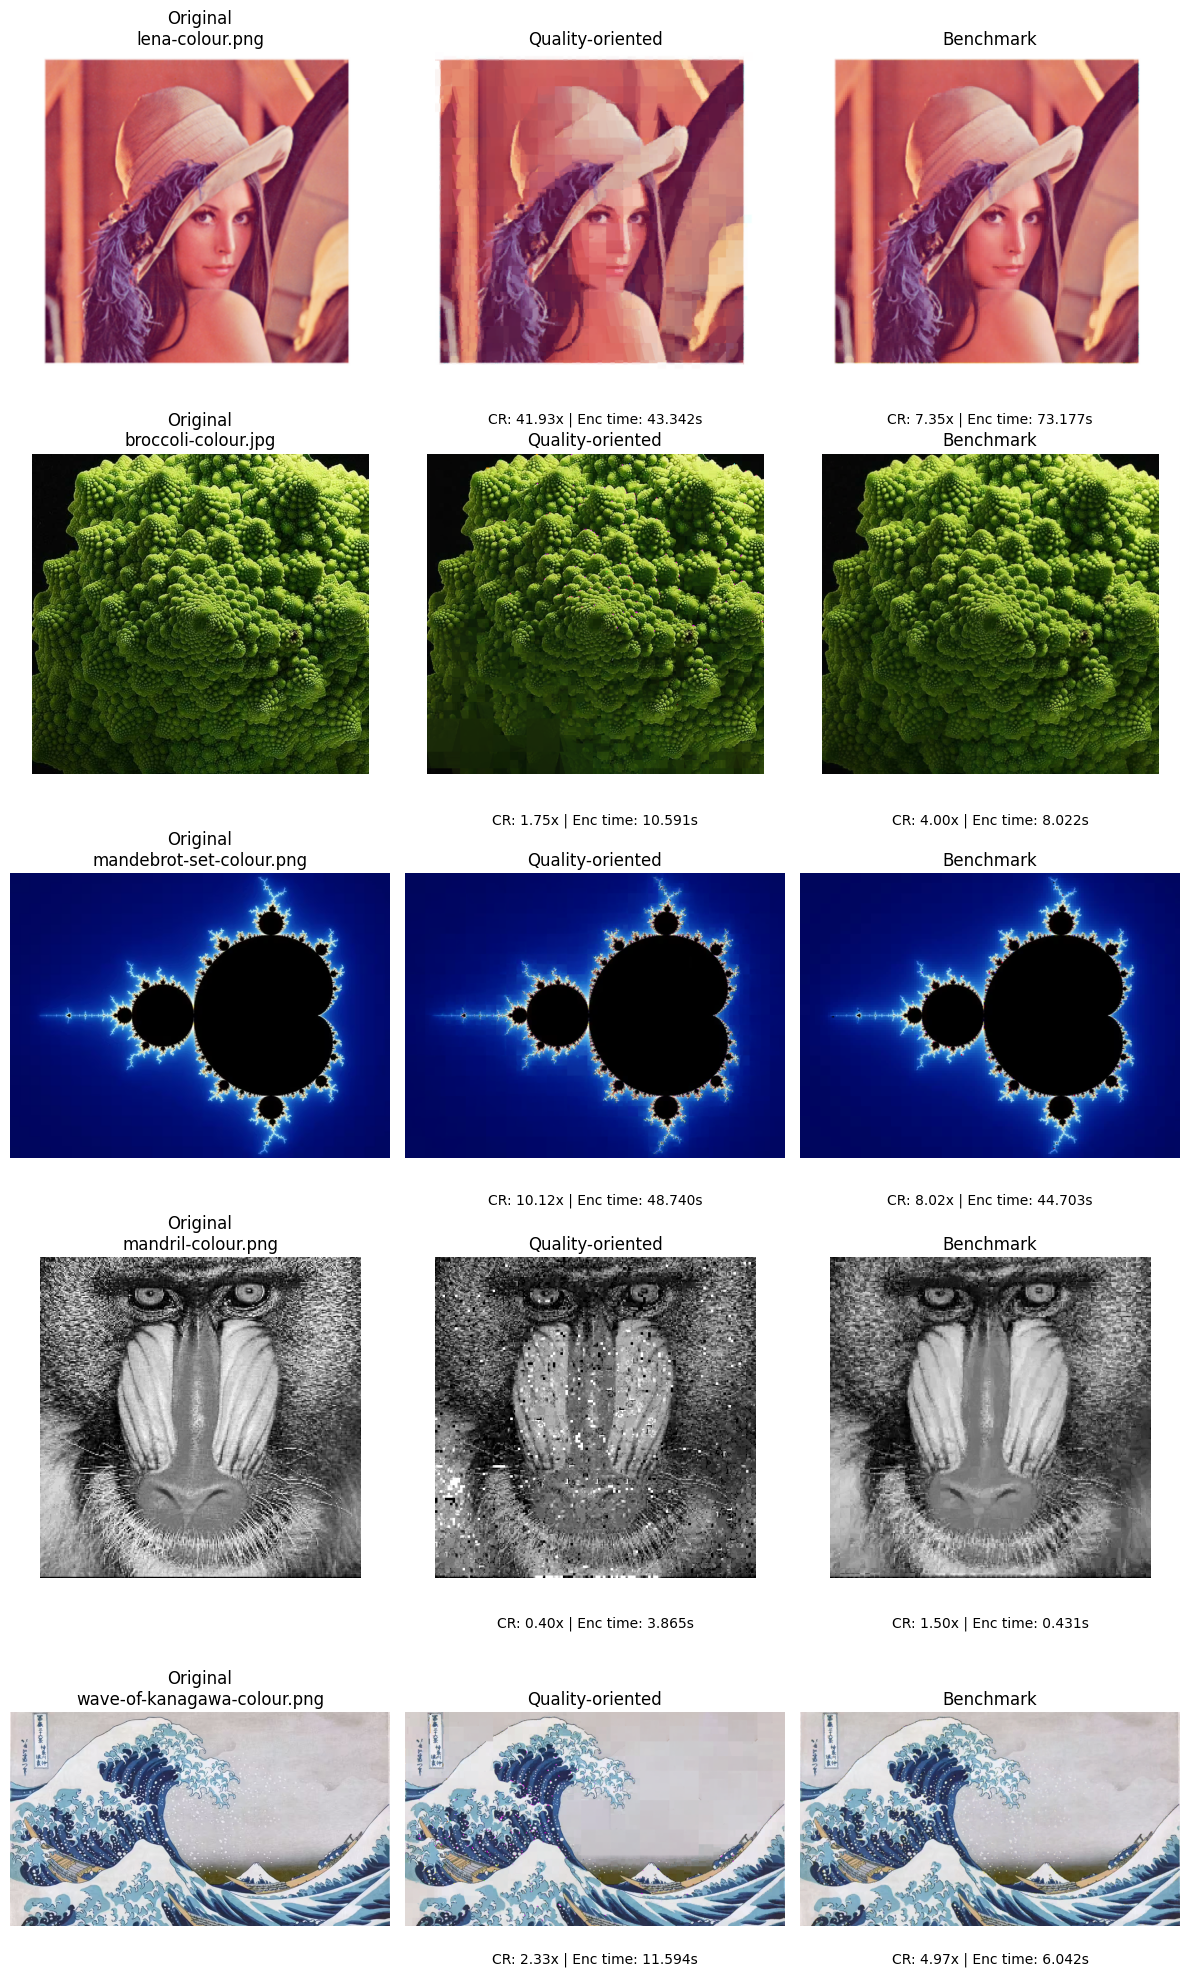

In [ ]:
import time
from pathlib import Path

import matplotlib.pyplot as plt

from fastfractal.core.encode import encode_array
from fastfractal.core.decode import decode_array
from fastfractal.io.imageio import load_image
from fastfractal.io.codebook import dump_code

SELECTED_FILES = [
    "lena-colour.png",
    "broccoli-colour.jpg",
    # "forrest2-colour.jpg",
    "mandebrot-set-colour.png",
    "mandril-colour.png",
    "wave-of-kanagawa-colour.png",
    # "flower-colour"
]

TEST_DIR = Path("../tests/test-data/")
RANDOM_SEED = 0
DECODE_ITERATIONS = 16

image_files = [TEST_DIR / filename for filename in SELECTED_FILES]

N_IMAGES = len(image_files)

QUALITY_CFG = dict(
    max_block=64,
    min_block=2,
    use_quadtree=True,
    max_mse=0.0025,
    use_buckets=True,
    bucket_count=32,
    stride=3,
    topk=64,
    quantized=True,
    entropy_thresh=0.0,
    max_domains=512,
    transform_ids="all",
)

SPEED_CFG = dict(
    max_block=16,
    min_block=4,
    use_quadtree=False,
    quantized=True,
    stride=4,
    topk=8,
    entropy_thresh=0.0,
    max_domains=128,
)

BENCH_CFG = dict(
    max_block=8,
    min_block=4,
    use_quadtree=True,
    quantized=True,
    max_mse=0.002,
    stride=12,
    topk=64,
)

fig, axes = plt.subplots(
    nrows=N_IMAGES,
    ncols=3,
    figsize=(12, 4 * N_IMAGES),
    squeeze=False,
)

for row, img_path in enumerate(image_files):
    original = load_image(img_path)
    orig_bytes = int(original.size)

    t0 = time.perf_counter()
    code_q = encode_array(original, **QUALITY_CFG)
    t_enc_q = time.perf_counter() - t0
    recon_q = decode_array(code_q, iterations=DECODE_ITERATIONS)
    q_bytes = len(dump_code(code_q))
    cr_q = float(orig_bytes) / float(max(1, q_bytes))

    t0 = time.perf_counter()
    code_s = encode_array(original, **BENCH_CFG)
    t_enc_s = time.perf_counter() - t0
    recon_s = decode_array(code_s, iterations=DECODE_ITERATIONS)
    s_bytes = len(dump_code(code_s))
    cr_s = float(orig_bytes) / float(max(1, s_bytes))

    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title(f"Original\n{img_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(recon_q, cmap="gray")
    axes[row, 1].set_title("Quality-oriented")
    axes[row, 1].axis("off")
    axes[row, 1].text(
        0.5,
        -0.12,
        f"CR: {cr_q:.2f}x | Enc time: {t_enc_q:.3f}s",
        ha="center",
        va="top",
        transform=axes[row, 1].transAxes,
        fontsize=10,
    )

    axes[row, 2].imshow(recon_s, cmap="gray")
    axes[row, 2].set_title("Benchmark")
    axes[row, 2].axis("off")
    axes[row, 2].text(
        0.5,
        -0.12,
        f"CR: {cr_s:.2f}x | Enc time: {t_enc_s:.3f}s",
        ha="center",
        va="top",
        transform=axes[row, 2].transAxes,
        fontsize=10,
    )

plt.tight_layout()
plt.show()

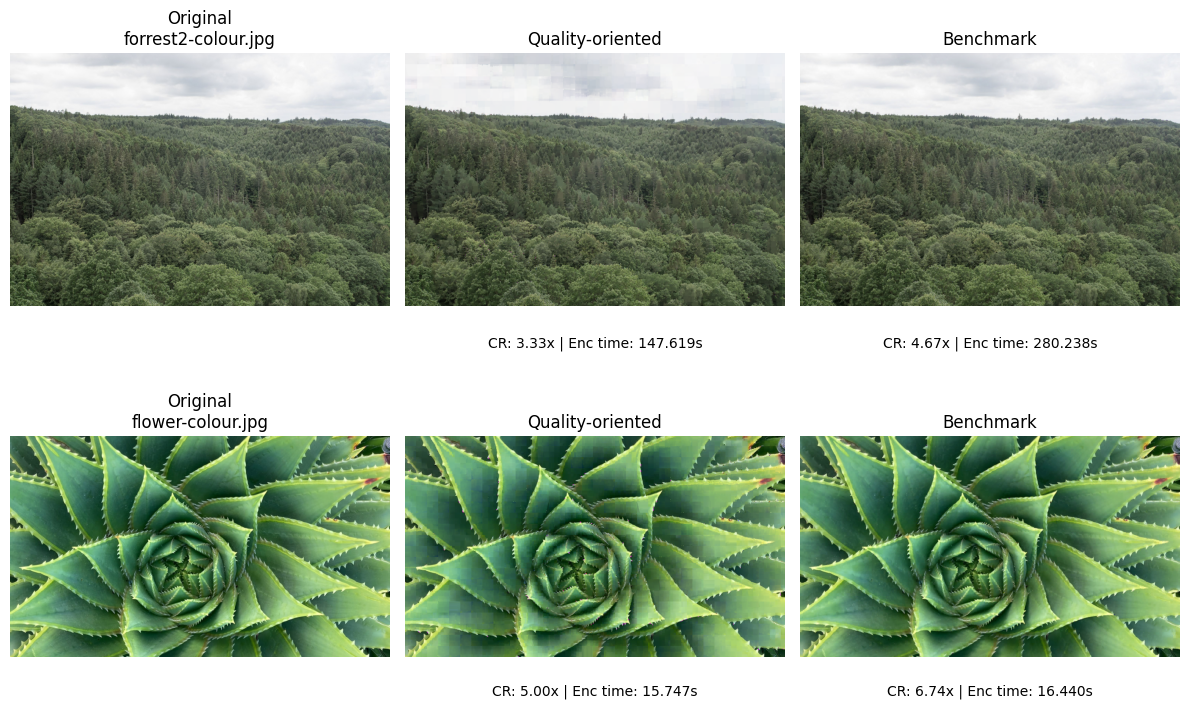

In [9]:
SELECTED_FILES = [
    # "lena-colour.png",
    # "broccoli-colour.jpg",
    "forrest2-colour.jpg",
    # "mandebrot-set-colour.png",
    # "mandril-colour.png",
    "flower-colour.jpg",
]

TEST_DIR = Path("../tests/test-data/")
RANDOM_SEED = 0
DECODE_ITERATIONS = 16

image_files = [TEST_DIR / filename for filename in SELECTED_FILES]

N_IMAGES = len(image_files)

QUALITY_CFG = dict(
    max_block=64,
    min_block=2,
    use_quadtree=True,
    max_mse=0.0025,
    use_buckets=True,
    bucket_count=32,
    stride=3,
    topk=64,
    quantized=True,
    entropy_thresh=0.0,
    max_domains=512,
    transform_ids="all",
)

BENCH_CFG = dict(
    max_block=8,
    min_block=4,
    use_quadtree=True,
    quantized=True,
    max_mse=0.002,
    stride=12,
    topk=64,
)

fig, axes = plt.subplots(
    nrows=N_IMAGES,
    ncols=3,
    figsize=(12, 4 * N_IMAGES),
    squeeze=False,
)

for row, img_path in enumerate(image_files):
    original = load_image(img_path)
    orig_bytes = int(original.size)

    t0 = time.perf_counter()
    code_q = encode_array(original, **QUALITY_CFG)
    t_enc_q = time.perf_counter() - t0
    recon_q = decode_array(code_q, iterations=DECODE_ITERATIONS)
    q_bytes = len(dump_code(code_q))
    cr_q = float(orig_bytes) / float(max(1, q_bytes))

    t0 = time.perf_counter()
    code_s = encode_array(original, **BENCH_CFG)
    t_enc_s = time.perf_counter() - t0
    recon_s = decode_array(code_s, iterations=DECODE_ITERATIONS)
    s_bytes = len(dump_code(code_s))
    cr_s = float(orig_bytes) / float(max(1, s_bytes))

    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title(f"Original\n{img_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(recon_q, cmap="gray")
    axes[row, 1].set_title("Quality-oriented")
    axes[row, 1].axis("off")
    axes[row, 1].text(
        0.5,
        -0.12,
        f"CR: {cr_q:.2f}x | Enc time: {t_enc_q:.3f}s",
        ha="center",
        va="top",
        transform=axes[row, 1].transAxes,
        fontsize=10,
    )

    axes[row, 2].imshow(recon_s, cmap="gray")
    axes[row, 2].set_title("Benchmark")
    axes[row, 2].axis("off")
    axes[row, 2].text(
        0.5,
        -0.12,
        f"CR: {cr_s:.2f}x | Enc time: {t_enc_s:.3f}s",
        ha="center",
        va="top",
        transform=axes[row, 2].transAxes,
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## Wizualizacja struktury podziału obrazu (Quadtree)

Ta sekcja kodu służy do "zajrzenia pod maskę" algorytmu i zrozumienia, w jaki sposób obraz jest analizowany i dzielony na mniejsze fragmenty w celu znalezienia autopodobieństw.

### Kluczowe etapy procesu:
1. **Kodowanie do formatu binarnego:** Funkcja `encode_to_file` zapisuje skompresowane dane do autorskiego formatu `.ffc` (Fast Fractal Code). To tutaj zapada decyzja o strukturze podziału obrazu na podstawie parametrów `max_block` i `min_block`.
2. **Generowanie mapy bloków:** Użycie funkcji `visualize_blocks_from_file` pozwala na nałożenie siatki bloków **Range** na zrekonstruowany obraz. 
3. **Analiza struktury:** Dzięki temu widzimy, jak działa mechanizm **Quadtree**:
    * **Duże bloki (16x16):** Pojawiają się w obszarach jednolitych, gdzie błąd dopasowania jest niski.
    * **Małe bloki (4x4):** Koncentrują się wokół krawędzi płatków kwiatu i detali o wysokim kontraście, gdzie wymagana jest większa precyzja.


In [10]:
from fastfractal.core.encode import encode_to_file
from pathlib import Path

ENCODE_KWARGS = dict(
    max_block=16,
    min_block=4,
    use_quadtree=True,
    quantized=True,
    max_mse=0.002,
    stride=12,
    topk=64,
)

OUT_DIR = Path("demo_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ENCODED_PATH = OUT_DIR / "encoded_flower.ffc"
BLOCKS_PATH = OUT_DIR / "blocks_flower.png"
DECODED_PATH = OUT_DIR / "decoded_flower.png"

IMAGE_PATH = Path(r"../tests/test-data/flower-colour.jpg")


encode_to_file(IMAGE_PATH, ENCODED_PATH, **ENCODE_KWARGS)

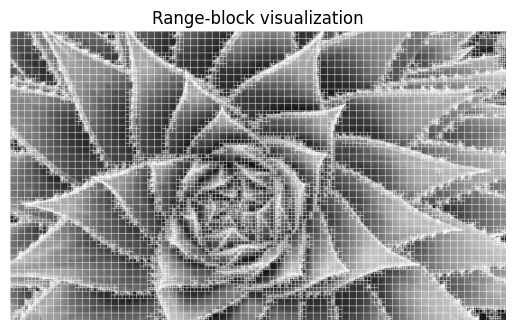

In [11]:
from PIL import Image

import matplotlib.pyplot as plt

visualize_blocks_from_file(
    ENCODED_PATH,
    BLOCKS_PATH,
    background="decode",
    grayscale=True,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

im_blocks = Image.open(BLOCKS_PATH).convert("L")
plt.figure()
plt.title("Range-block visualization")
plt.axis("off")
plt.imshow(im_blocks, cmap="gray", vmin=0, vmax=255)
plt.show()

In [ ]:
OUT_DIR = Path("demo_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
ENCODED_PATH_HIGH = OUT_DIR / "encoded_wave_high.ffc"
BLOCKS_PATH_HIGH = OUT_DIR / "blocks_wave_high.png"
DECODED_PATH_HIGH = OUT_DIR / "decoded_wave_high.png"

IMAGE_PATH = Path(r"../tests/test-data/wave-of-kanagawa-colour.png")

encode_to_file(IMAGE_PATH, ENCODED_PATH_HIGH, **ENCODE_KWARGS)

visualize_blocks_from_file(
    ENCODED_PATH_HIGH,
    BLOCKS_PATH_HIGH,
    background="decode",
    grayscale=False,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

ENCODED_PATH_LOW = OUT_DIR / "encoded_wave_low.ffc"
BLOCKS_PATH_LOW = OUT_DIR / "blocks_wave_low.png"
DECODED_PATH_LOW = OUT_DIR / "decoded_wave_low.png"

encode_to_file(IMAGE_PATH, ENCODED_PATH_LOW, **SPEED_CFG)

visualize_blocks_from_file(
    ENCODED_PATH_LOW,
    BLOCKS_PATH_LOW,
    background="decode",
    grayscale=False,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

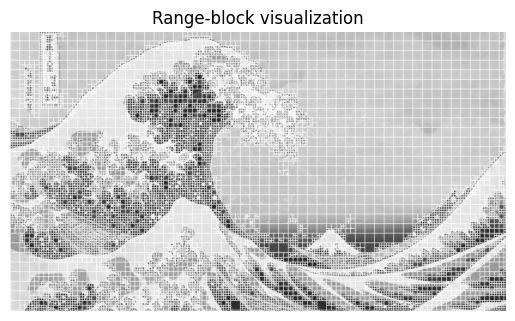

In [13]:
visualize_blocks_from_file(
    ENCODED_PATH,
    BLOCKS_PATH,
    background="decode",
    grayscale=True,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

im_blocks = Image.open(BLOCKS_PATH).convert("L")
plt.figure()
plt.title("Range-block visualization")
plt.axis("off")
plt.imshow(im_blocks, cmap="gray", vmin=0, vmax=255)
plt.show()

In [22]:
IMAGE_PATH = Path(r"../tests/test-data/fush.jfif")
ENCODED_PATH_HIGH = OUT_DIR / "encoded_fush_high.ffc"
BLOCKS_PATH_HIGH = OUT_DIR / "blocks_fush_high.png"
DECODED_PATH_HIGH = OUT_DIR / "decoded_fush_high.png"

encode_to_file(IMAGE_PATH, ENCODED_PATH_HIGH, **QUALITY_CFG)

visualize_blocks_from_file(
    ENCODED_PATH_HIGH,
    BLOCKS_PATH_HIGH,
    background="decode",
    grayscale=False,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

ENCODED_PATH_LOW = OUT_DIR / "encoded_fush_low.ffc"
BLOCKS_PATH_LOW = OUT_DIR / "blocks_fush_low.png"
DECODED_PATH_LOW = OUT_DIR / "decoded_fush_low.png"

encode_to_file(IMAGE_PATH, ENCODED_PATH_LOW, **SPEED_CFG)

visualize_blocks_from_file(
    ENCODED_PATH_LOW,
    BLOCKS_PATH_LOW,
    background="decode",
    grayscale=False,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

WindowsPath('demo_out/blocks_fush_low.png')

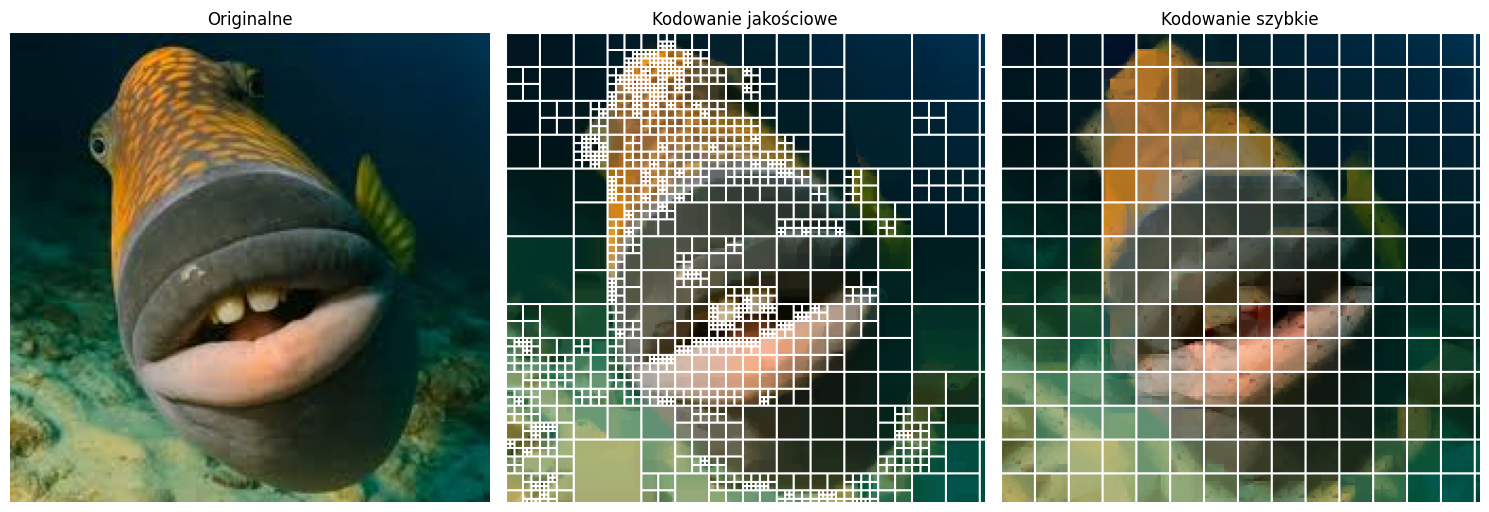

In [25]:
im1 = Image.open(IMAGE_PATH).convert("RGB")
im2 = Image.open(BLOCKS_PATH_HIGH).convert("RGB")
im3 = Image.open(BLOCKS_PATH_LOW).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, im, title in zip(
    axes,
    [im1, im2, im3],
    ["Originalne", "Kodowanie jakościowe", "Kodowanie szybkie"]
):
    ax.set_title(title)
    ax.axis("off")
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)

plt.tight_layout()
plt.show()


In [26]:
IMAGE_PATH = Path(r"../tests/test-data/bhutan-map.jpg")
ENCODED_PATH_HIGH = OUT_DIR / "encoded_bhutan_high.ffc"
BLOCKS_PATH_HIGH = OUT_DIR / "blocks_bhutan_high.png"
DECODED_PATH_HIGH = OUT_DIR / "decoded_bhutan_high.png"

encode_to_file(IMAGE_PATH, ENCODED_PATH_HIGH, **QUALITY_CFG)

visualize_blocks_from_file(
    ENCODED_PATH_HIGH,
    BLOCKS_PATH_HIGH,
    background="decode",
    grayscale=False,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

ENCODED_PATH_LOW = OUT_DIR / "encoded_bhutan_low.ffc"
BLOCKS_PATH_LOW = OUT_DIR / "blocks_bhutan_low.png"
DECODED_PATH_LOW = OUT_DIR / "decoded_bhutan_low.png"

encode_to_file(IMAGE_PATH, ENCODED_PATH_LOW, **SPEED_CFG)

visualize_blocks_from_file(
    ENCODED_PATH_LOW,
    BLOCKS_PATH_LOW,
    background="decode",
    grayscale=False,
    iterations=16,
    thickness=1,
    alpha=1.0,
    upscale=2,
)

WindowsPath('demo_out/blocks_bhutan_low.png')

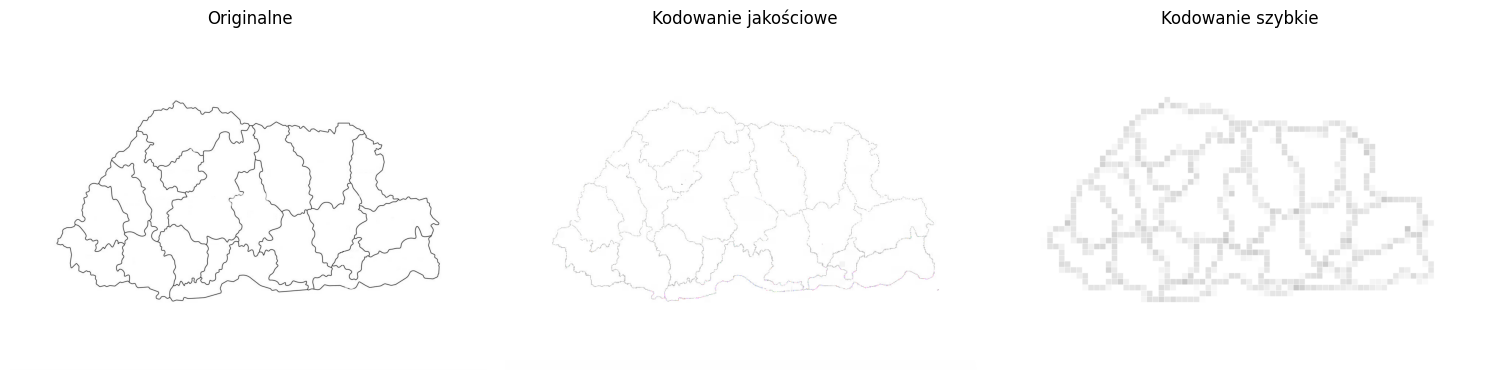

In [27]:
im1 = Image.open(IMAGE_PATH).convert("RGB")
im2 = Image.open(BLOCKS_PATH_HIGH).convert("RGB")
im3 = Image.open(BLOCKS_PATH_LOW).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, im, title in zip(
    axes,
    [im1, im2, im3],
    ["Originalne", "Kodowanie jakościowe", "Kodowanie szybkie"]
):
    ax.set_title(title)
    ax.axis("off")
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)

plt.tight_layout()
plt.show()